<a href="https://colab.research.google.com/github/srinidhishamanthula/NASCOM/blob/main/U3_Python_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup complete. NumPy 2.0.2 | Pandas 2.2.2
Array a:
 [[0 1 2]
 [3 4 5]]
shape : (2, 3)
ndim  : 2
dtype : int64
Column index 1 : [1 4]
Row index 0    : [0 1 2]
Elements > 2   : [3 4 5]
a + row (row added to every row of a):
 [[10 21 32]
 [13 24 35]]
Matrix product a @ b:
 [[ 3  3]
 [12 12]]
Column-wise sum  (axis=0): [3 5 7]
Row-wise sum     (axis=1): [ 3 12]
Row-wise mean    (axis=1): [1. 4.]
Index of max per column  : [1 1 1]
M:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
N:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
M:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
N:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
M @ N:
 [[ 50  60]
 [114 140]
 [178 220]]
Column-wise sum: [15 18 21 24]
Row-wise mean: [ 2.5  6.5 10.5]
Index of maximum value in each row: [3 3 3]
M:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
N:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
M @ N:
 [[ 50  60]
 [114 140]
 [178 220]]
Column-wise sum: [15 18 21 24]
Row-wise mean: [ 2.5  6.5 10.5]
Index of maximum value in each row: [3 3 3]
Shape: (891, 15)
<clas

/tmp/ipykernel_2784/3437321641.py:92: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lab['embarked'].fillna(lab['embarked'].mode()[0], inplace=True)


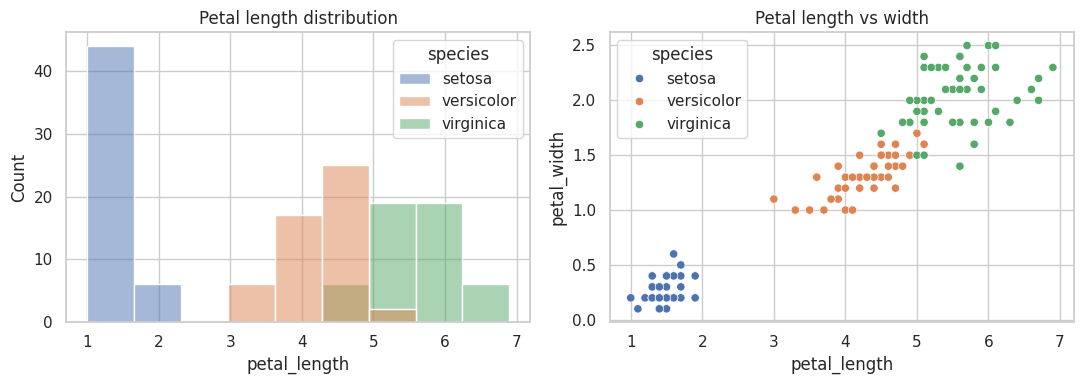

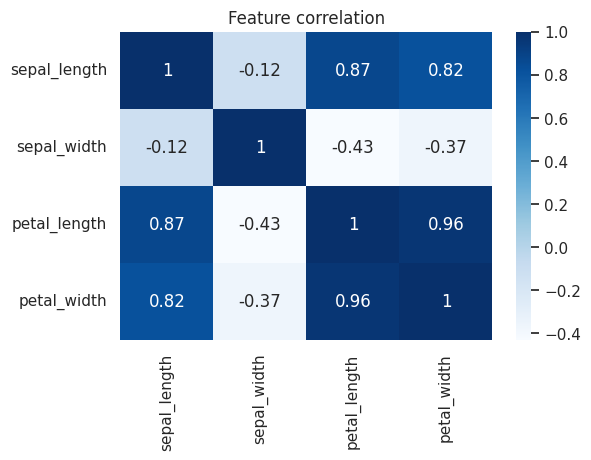

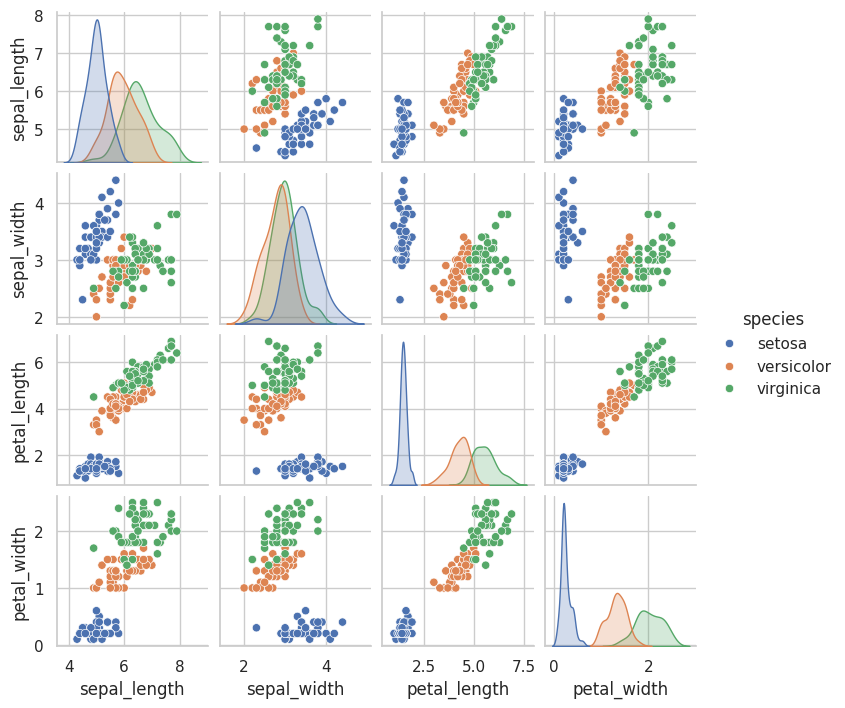

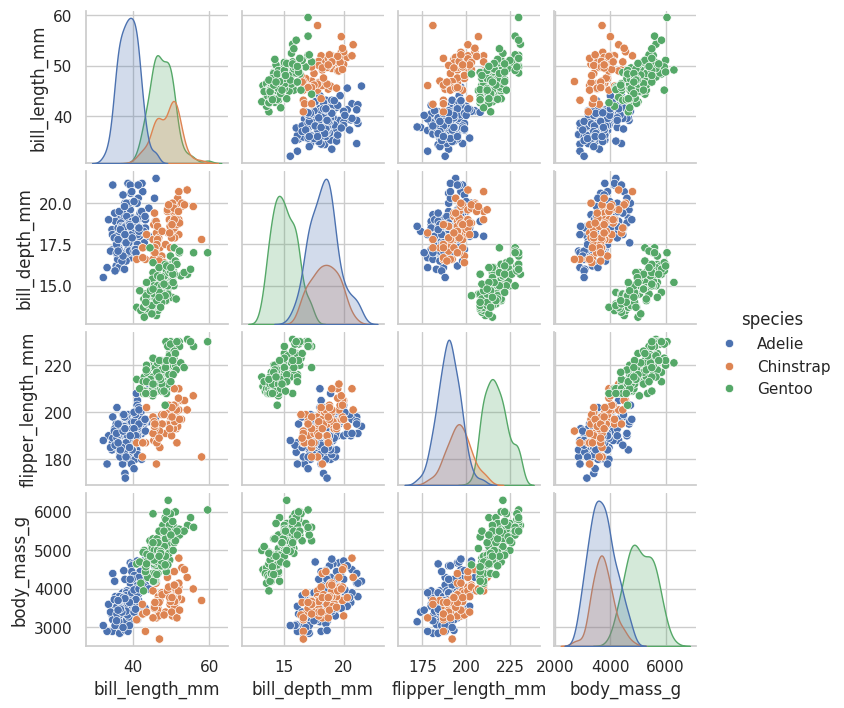

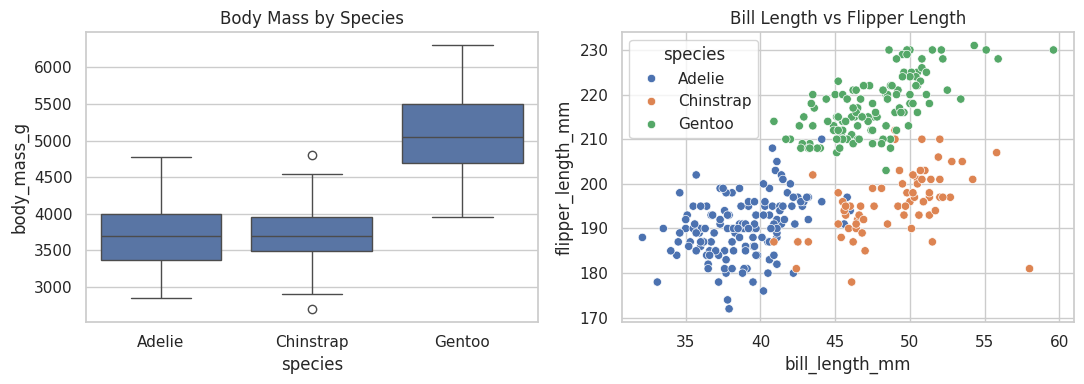

Features X: (150, 4) | Target y: (150,)
Train: 120 samples | Test: 30 samples
Accuracy: 0.9
Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]
Pipeline accuracy: 0.933
Breast cancer data: (569, 30)
Test accuracy: 0.958
End-to-end Titanic survival accuracy: 0.793


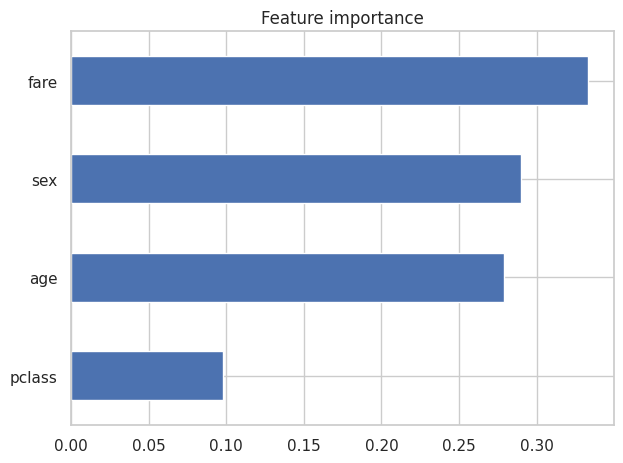

End-to-end Iris classification accuracy: 1.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme(style='whitegrid')
np.random.seed(42)
print('Setup complete. NumPy', np.__version__, '| Pandas', pd.__version__)

a = np.arange(6).reshape(2, 3)
print('Array a:\n', a)
print('shape :', a.shape)
print('ndim  :', a.ndim)
print('dtype :', a.dtype)

print('Column index 1 :', a[:, 1])
print('Row index 0    :', a[0, :])
print('Elements > 2   :', a[a > 2])

row = np.array([10, 20, 30])
print('a + row (row added to every row of a):\n', a + row)


b = np.ones((3, 2), dtype=int)
print('Matrix product a @ b:\n', a @ b)
print('Column-wise sum  (axis=0):', a.sum(axis=0))
print('Row-wise sum     (axis=1):', a.sum(axis=1))
print('Row-wise mean    (axis=1):', a.mean(axis=1))
print('Index of max per column  :', a.argmax(axis=0))

M = np.arange(1, 13).reshape(3, 4)
N = np.arange(1, 9).reshape(4, 2)
print('M:\n', M)
print('N:\n', N)
M = np.arange(1, 13).reshape(3, 4)
N = np.arange(1, 9).reshape(4, 2)

print('M:\n', M)
print('N:\n', N)
result = M @ N
print("M @ N:\n", result)
col_sum = M.sum(axis=0)
row_mean = M.mean(axis=1)

print("Column-wise sum:", col_sum)
print("Row-wise mean:", row_mean)
max_index = M.argmax(axis=1)
print("Index of maximum value in each row:", max_index)

M = np.arange(1, 13).reshape(3, 4)
N = np.arange(1, 9).reshape(4, 2)

print('M:\n', M)
print('N:\n', N)
result = M @ N
print("M @ N:\n", result)
col_sum = M.sum(axis=0)
row_mean = M.mean(axis=1)

print("Column-wise sum:", col_sum)
print("Row-wise mean:", row_mean)
max_index = M.argmax(axis=1)
print("Index of maximum value in each row:", max_index)

df = sns.load_dataset('titanic')

print('Shape:', df.shape)
df.head()
df.info()
df.describe()
print('Missing values per column:')
print(df.isna().sum().sort_values(ascending=False).head())
df['age'] = df['age'].fillna(df['age'].median())
print('\nMissing ages after fillna:', df['age'].isna().sum())
print('Survival rate by class:')
print(df.groupby('class', observed=True)['survived'].mean())
print('\nSurvival rate by class and sex:')
print(df.groupby(['class', 'sex'], observed=True)['survived'].mean())

import seaborn as sns

lab = sns.load_dataset('titanic')
print("Missing values in 'embarked':", lab['embarked'].isna().sum())
lab['embarked'].fillna(lab['embarked'].mode()[0], inplace=True)
print("Missing values after filling:", lab['embarked'].isna().sum())
print("\nMean fare by sex:")
print(lab.groupby('sex', observed=True)['fare'].mean())

iris = sns.load_dataset('iris')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=iris, x='petal_length', hue='species', ax=axes[0])
axes[0].set_title('Petal length distribution')

sns.scatterplot(data=iris, x='petal_length', y='petal_width',
                hue='species', ax=axes[1])
axes[1].set_title('Petal length vs width')

plt.tight_layout()
plt.show()
plt.figure(figsize=(6, 4))
sns.heatmap(iris.drop(columns='species').corr(),
            annot=True, cmap='Blues')
plt.title('Feature correlation')
plt.show()
sns.pairplot(iris, hue='species', height=1.8)
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

pen = sns.load_dataset('penguins')

pen = pen.dropna()

sns.pairplot(pen, hue='species', height=1.8)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=pen, x='species', y='body_mass_g', ax=axes[0])
axes[0].set_title('Body Mass by Species')
sns.scatterplot(
    data=pen,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='species',
    ax=axes[1]
)
axes[1].set_title('Bill Length vs Flipper Length')

plt.tight_layout()
plt.show()

X, y = load_iris(return_X_y=True)
print('Features X:', X.shape, '| Target y:', y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape[0], 'samples | Test:', X_test.shape[0], 'samples')
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 3))
print('Confusion matrix:\n', confusion_matrix(y_test, pred))
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200))
])

pipe.fit(X_train, y_train)
print('Pipeline accuracy:', round(pipe.score(X_test, y_test), 3))

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

Xb, yb = load_breast_cancer(return_X_y=True)
print("Breast cancer data:", Xb.shape)
X_train, X_test, y_train, y_test = train_test_split(
    Xb, yb,
    test_size=0.25,
    random_state=0,
    stratify=yb
)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200))
])
pipe.fit(X_train, y_train)
print("Test accuracy:", round(pipe.score(X_test, y_test), 3))

data = sns.load_dataset('titanic')

data = data[['survived', 'pclass', 'sex', 'age', 'fare']].copy()
data['age'] = data['age'].fillna(data['age'].median())
data['sex'] = np.where(data['sex'] == 'male', 0, 1)
data = data.dropna()
X = data.drop(columns='survived').values
y = data['survived'].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42).fit(X_tr, y_tr)
acc = accuracy_score(y_te, model.predict(X_te))
print('End-to-end Titanic survival accuracy:', round(acc, 3))

importances = pd.Series(model.feature_importances_,
                        index=data.drop(columns='survived').columns)
importances.sort_values().plot.barh(title='Feature importance')
plt.tight_layout(); plt.show()

import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
data = sns.load_dataset("iris")
X = data.drop(columns="species").values
y = data["species"].values
le = LabelEncoder()
y = le.fit_transform(y)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = RandomForestClassifier(random_state=42)
model.fit(X_tr, y_tr)
acc = accuracy_score(y_te, model.predict(X_te))
print("End-to-end Iris classification accuracy:", round(acc, 3))


